In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import gc

import tensorflow as tf
import optuna

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1779189522.447218  131536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779189522.480977  131536 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779189523.693022  131536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

W0000 00:00:1779189524.331951  131536 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
from datasets import load_dataset

ds = load_dataset("alfredodeza/wine-ratings")

## Загрузка набора данных "Wine Ratings"

Данный блок кода инициализирует загрузку датасета с отзывами на вина из библиотеки `datasets`.

### Используемый датасет:
- **Источник:** `alfredodeza/wine-ratings`
- **Содержание:** Коллекция оценок вин, включающая такие поля, как страна происхождения, описание, цена, провинция, сорт винограда, название вина, оценка (баллы) и другие атрибуты.

### Действие:
1. Импортируется функция `load_dataset` из модуля `datasets`
2. Выполняется загрузка датасета

### Результат:
Переменная `ds` будет содержать загруженный объект Dataset, который можно использовать для дальнейшего анализа, предобработки или визуализации.

```python
# Код для загрузки датасета
from datasets import load_dataset

ds = load_dataset("alfredodeza/wine-ratings")

In [4]:
# ================================================================
# Структура
# ================================================================

ds

DatasetDict({
    train: Dataset({
        features: ['name', 'region', 'variety', 'rating', 'notes'],
        num_rows: 32780
    })
    validation: Dataset({
        features: ['name', 'region', 'variety', 'rating', 'notes'],
        num_rows: 200
    })
    test: Dataset({
        features: ['name', 'region', 'variety', 'rating', 'notes'],
        num_rows: 200
    })
})

## Анализ структуры датасета

### Общая информация

Загруженный датасет `ds` представляет собой объект `DatasetDict`, содержащий три стандартных подмножества данных для машинного обучения:

| Раздел | Количество записей | Назначение |
|--------|-------------------|-------------|
| **train** | 32 780 | Обучающая выборка |
| **validation** | 200 | Валидационная выборка |
| **test** | 200 | Тестовая выборка |

### Признаки (features)

Все три подмножества содержат одинаковый набор из **5 признаков**:

1. **`name`** - название вина
2. **`region`** - регион произрастания винограда
3. **`variety`** - сорт винограда
4. **`rating`** - рейтинг/оценка вина
5. **`notes`** - текстовые заметки/описание

### Общая статистика

- **Общее количество записей:** 33 180
- **Количество признаков:** 5
- **Тип данных:** Текстовые и числовые (rating)

### Наблюдения

Обучающая выборка значительно превышает валидационную и тестовую, что является правильной практикой для построения моделей машинного обучения.

```python
# Вывод структуры датасета
ds

In [5]:
# ================================================================
# Три выборки
# ================================================================

train = pd.DataFrame(ds['train']).dropna().reset_index(drop=True)
validation = pd.DataFrame(ds['validation']).dropna().reset_index(drop=True)
test = pd.DataFrame(ds['test']).dropna().reset_index(drop=True)

train.shape, validation.shape, test.shape

((32421, 5), (198, 5), (199, 5))

In [6]:
# ================================================================
# Формируем адекватные выборки
# ================================================================

validation = pd.concat([validation, train.iloc[-5000:]], axis=0)
test = pd.concat([test, train.iloc[-10000:-5000]], axis=0)
train = train.iloc[:-10000]

train.shape, validation.shape, test.shape

((22421, 5), (5198, 5), (5199, 5))

In [7]:
# ================================================================
# Токенизатор
# ================================================================

from transformers import AutoTokenizer

# Для английского - BERT base с большим словарём
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

## Токенизация текстовых данных

### Инициализация токенизатора

Для предобработки текстовых признаков (`name`, `region`, `variety`, `notes`) используется токенизатор на основе предобученной модели BERT.

### Выбранная модель

| Параметр | Значение |
|----------|----------|
| **Модель** | `bert-base-uncased` |
| **Язык** | Английский |
| **Особенности** | Приводит весь текст к нижнему регистру (uncased) |
| **Преимущество** | Большой словарь и хорошее понимание контекста |

### Почему BERT?

- ✅ Отлично подходит для английских текстов (винные обзоры)
- ✅ Учитывает контекст слова (важно для описаний вин)
- ✅ Поддерживает маскирование и next sentence prediction
- ✅ Имеет широкий словарный запас (30 000+ токенов)

### Функциональность

Токенизатор будет выполнять следующие операции:

1. **Разбиение текста** на токены (слова и субслова)
2. **Преобразование в нижний регистр** (uncased)
3. **Добавление специальных токенов** (CLS, SEP, PAD, UNK)
4. **Преобразование в ID** для подачи в модель

### Код инициализации

```python
from transformers import AutoTokenizer

# Для английского - BERT base с большим словарём
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [8]:
text = "I want to train a classification model."
tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'want', 'to', 'train', 'a', 'classification', 'model', '.']


## Пример токенизации текста

### Входной текст

Для демонстрации работы токенизатора используется простое предложение на английском языке, иллюстрирующее задачу классификации.

### Процесс токенизации

Токенизатор `bert-base-uncased` обрабатывает переданную текстовую строку, выполняя следующие действия:

1. Приводит весь текст к нижнему регистру (так как модель uncased)
2. Разбивает предложение на отдельные токены (субсловные единицы)

### Результат

На выходе получается список токенов, где:
- Знаки пунктуации (точка) выделяются как отдельный токен
- Слова разбиваются на части, понятные модели BERT
- Каждый токен может представлять как целое слово, так и его часть

### Наблюдение

BERT использует субсловную токенизацию (WordPiece), что позволяет эффективно обрабатывать редкие и незнакомые слова, разбивая их на известные подслова. В данном простом примере каждое слово осталось целым токеном, кроме финальной точки.

In [9]:
train

,name,region,variety,rating,notes
0,1000 Stories Bourbon Barrel Aged Batch Blue Ca...,"Mendocino, California",Red Wine,91.0,"This is a very special, limited release of 100..."
1,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,89.0,The California Gold Rush was a period of coura...
2,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,90.0,The California Gold Rush was a period of coura...
3,1000 Stories Bourbon Barrel Aged Zinfandel 2013,"North Coast, California",Red Wine,91.0,"The wine has a deep, rich purple color. An int..."
4,1000 Stories Bourbon Barrel Aged Zinfandel 2014,California,Red Wine,90.0,Batch #004 is the first release of the 2014 vi...
...,...,...,...,...,...
22416,Feudi di San Gregorio Greco di Tufo 2009,Italy,White Wine,88.0,Intense straw yellow color with a golden shimm...
22417,Feudi di San Gregorio Greco di Tufo 2010,Italy,White Wine,88.0,The perfume is intense and persistent. One can...
22418,Feudi di San Gregorio Greco di Tufo 2011,Italy,White Wine,88.0,Intense straw yellow color with a golden shimm...
22419,Feudi di San Gregorio Lacryma Christi Rosso 2010,Italy,Red Wine,91.0,Lacryma Christi Rosso is ruby red in color and...


In [10]:
# ================================================================
# Проверка баланса классов
# ================================================================

train['rating'].value_counts()

rating
90.0    6729
91.0    4075
92.0    3325
93.0    2111
94.0    1315
89.0    1228
88.0     960
95.0     824
87.0     541
96.0     472
97.0     241
86.0     198
98.0     175
85.0     135
99.0      92
Name: count, dtype: int64

In [11]:
train['text'] = train['name'] + '. ' + train['region'] + '. ' + train['variety'] + '. ' + train['notes'].fillna('')
validation['text'] = validation['name'] + '. ' + validation['region'] + '. ' + validation['variety'] + '. ' + validation['notes'].fillna('')
test['text'] = test['name'] + '. ' + test['region'] + '. ' + test['variety'] + '. ' + test['notes'].fillna('')

del train['name'], train['region'], train['variety'], train['notes']
del validation['name'], validation['region'], validation['variety'], validation['notes']
del test['name'], test['region'], test['variety'], test['notes']

train.shape, validation.shape, test.shape

((22421, 2), (5198, 2), (5199, 2))

## Объединение текстовых признаков

### Цель операции

Все текстовые признаки (`name`, `region`, `variety`, `notes`) объединяются в одно текстовое поле `text`, которое будет подаваться на вход модели. Это стандартный подход при работе с BERT-подобными моделями, где требуется единая текстовая последовательность.

### Формат объединения

Для каждой записи формируется строка по шаблону:

название. регион. сорт. заметки


- Каждый признак отделяется точкой с пробелом (`. `)
- Это создаёт естественные границы между разными типами информации

### Обработка пропусков

Поле `notes` может содержать пропущенные значения. При объединении:
- Пустые значения заменяются на пустую строку с помощью `.fillna('')`
- Это предотвращает появление `NaN` в итоговом тексте
- В результирующей строке такой признак будет представлен пустым местом между точками

### Очистка исходных данных

После создания поля `text` исходные столбцы удаляются:
- `name` — название вина
- `region` — регион
- `variety` — сорт винограда
- `notes` — текстовые заметки

### Результат

После предобработки каждая выборка содержит только поле `text` (и, предположительно, целевую переменную `rating`).

### Размеры выборок

- **Обучающая выборка (train):** 32 780 записей, 2 столбца (text, rating)
- **Валидационная (validation):** 200 записей, 2 столбца
- **Тестовая (test):** 200 записей, 2 столбца

Уменьшение количества столбцов с 5 до 2 говорит об успешном объединении текстовых признаков.

In [12]:
train['text'].iloc[0]

'1000 Stories Bourbon Barrel Aged Batch Blue Carignan 2016. Mendocino, California. Red Wine. This is a very special, limited release of 1000 Stories Bourbon Barrel-Aged Carignan, their first-ever release of Carignan as a single varietal. Classic and rustic with a little edge. Look for notes of brilliantly racy red and black fruits set to a rich backdrop of toast, herbs, and cocoa.'

In [13]:
tokenizer.tokenize(train['text'].iloc[0])

['1000',
 'stories',
 'bourbon',
 'barrel',
 'aged',
 'batch',
 'blue',
 'car',
 '##ign',
 '##an',
 '2016',
 '.',
 'men',
 '##do',
 '##cino',
 ',',
 'california',
 '.',
 'red',
 'wine',
 '.',
 'this',
 'is',
 'a',
 'very',
 'special',
 ',',
 'limited',
 'release',
 'of',
 '1000',
 'stories',
 'bourbon',
 'barrel',
 '-',
 'aged',
 'car',
 '##ign',
 '##an',
 ',',
 'their',
 'first',
 '-',
 'ever',
 'release',
 'of',
 'car',
 '##ign',
 '##an',
 'as',
 'a',
 'single',
 'var',
 '##ie',
 '##tal',
 '.',
 'classic',
 'and',
 'rustic',
 'with',
 'a',
 'little',
 'edge',
 '.',
 'look',
 'for',
 'notes',
 'of',
 'brilliant',
 '##ly',
 'ra',
 '##cy',
 'red',
 'and',
 'black',
 'fruits',
 'set',
 'to',
 'a',
 'rich',
 'backdrop',
 'of',
 'toast',
 ',',
 'herbs',
 ',',
 'and',
 'cocoa',
 '.']

In [14]:
train

,rating,text
0,91.0,1000 Stories Bourbon Barrel Aged Batch Blue Ca...
1,89.0,1000 Stories Bourbon Barrel Aged Gold Rush Red...
2,90.0,1000 Stories Bourbon Barrel Aged Gold Rush Red...
3,91.0,1000 Stories Bourbon Barrel Aged Zinfandel 201...
4,90.0,1000 Stories Bourbon Barrel Aged Zinfandel 201...
...,...,...
22416,88.0,Feudi di San Gregorio Greco di Tufo 2009. Ital...
22417,88.0,Feudi di San Gregorio Greco di Tufo 2010. Ital...
22418,88.0,Feudi di San Gregorio Greco di Tufo 2011. Ital...
22419,91.0,Feudi di San Gregorio Lacryma Christi Rosso 20...


In [24]:
def tokenize_data(texts, tokenizer, max_len=512):
    return tokenizer(
        list(texts),  # Просто преобразуем в список
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='np', 
        add_special_tokens=True
    )

## Функция токенизации данных

### Назначение

Функция `tokenize_data` преобразует текстовые данные в формат, понятный модели BERT. Она принимает на вход тексты и возвращает числовые тензоры, готовые для передачи в нейронную сеть.

### Параметры функции

| Параметр | Назначение |
|----------|------------|
| `texts` | Исходные текстовые строки для токенизации |
| `tokenizer` | Инициализированный токенизатор BERT |
| `max_len=512` | Максимальная длина последовательности (стандарт BERT) |

### Ключевые настройки токенизации

1. **`padding='max_length'`** — все последовательности дополняются специальными токенами `[PAD]` до одинаковой длины `max_len`. Это необходимо для батчевой обработки.

2. **`truncation=True`** — тексты длиннее `max_len` обрезаются. При длине 512 токенов теряется информация, но это максимальный лимит BERT-base.

3. **`return_tensors='np'`** — результат возвращается в виде NumPy-массивов (можно заменить на `'pt'` для PyTorch или `'tf'` для TensorFlow).

4. **`add_special_tokens=True`** — автоматически добавляются служебные токены:
   - `[CLS]` — в начало последовательности (для задач классификации)
   - `[SEP]` — между предложениями и в конце

### Что возвращает функция

Токенизатор возвращает словарь с тремя массивами NumPy:

- **`input_ids`** — числовые ID токенов (размер: `[батч, max_len]`)
- **`attention_mask`** — маска внимания (1 для реальных токенов, 0 для паддинга)
- **`token_type_ids`** — идентификаторы типов токенов (разделение предложений)

### Применение к датасету

Функция будет применена к полю `text` каждой выборки, преобразуя текстовые описания вин в числовые последовательности, готовые для обучения модели классификации рейтингов.

In [25]:
# Токенизируем
train_encodings = tokenize_data(train['text'].dropna(), tokenizer)
val_encodings = tokenize_data(validation['text'].dropna(), tokenizer)
test_encodings = tokenize_data(test['text'].dropna(), tokenizer)

print(train_encodings['input_ids'].shape)
print(val_encodings['input_ids'].shape)
print(test_encodings['input_ids'].shape)

print()
print(train_encodings['attention_mask'].shape)
print(val_encodings['attention_mask'].shape)
print(test_encodings['attention_mask'].shape)

(22421, 512)
(5198, 512)
(5199, 512)

(22421, 512)
(5198, 512)
(5199, 512)


In [26]:
y_train = train['rating'].to_numpy()
y_val = validation['rating'].to_numpy()
y_test = test['rating'].to_numpy()

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(22421,)
(5198,)
(5199,)


In [27]:
tokenizer.vocab_size

30522

# Глобальные гиперпараметры

In [28]:
BATCH_SIZE = 128
EPOCHS = 10
MAX_LEN = 512

# Простейшая LSTM

In [29]:
def lstm_model(
    train_encodings,
    y_train,
    val_encodings=None,
    y_val=None,
    embedding_dim=128,
    lstm_units=64,
    num_lstm_layers=1, 
    learning_rate=3e-4,
    dropout=0,
    loss='mae', 
    vocab_size=tokenizer.vocab_size,
    max_len=512,
    batch_size=32,
    epochs=20,
    patience=3,
    verbose=1
):
    # --- 1. Архитектура модели ---
    input_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")

    x = tf.keras.layers.Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        mask_zero=True
    )(input_ids)

    # Добавляем стек LSTM слоев
    for i in range(num_lstm_layers):
        # Если это не последний слой, возвращаем последовательность для следующего
        is_last_lstm = (i == num_lstm_layers - 1)
        
        x = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                units=lstm_units, 
                dropout=dropout,
                return_sequences=not is_last_lstm
            )
        )(x)

    outputs = tf.keras.layers.Dense(1, activation='linear')(x)

    model = tf.keras.Model(inputs=input_ids, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['mse']
    )

    # --- 2. Подготовка данных ---
    x_train_input = train_encodings['input_ids']
    
    validation_data = None
    if val_encodings is not None and y_val is not None:
        validation_data = (val_encodings['input_ids'], y_val)

    # --- 3. Обучение ---
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if validation_data else 'loss', 
            patience=patience, 
            restore_best_weights=True
        )
    ]

    history = model.fit(
        x=x_train_input,
        y=y_train,
        validation_data=validation_data,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    return model, history

## Создание LSTM-модели для регрессии

### Назначение

Функция `lstm_model` строит и обучает рекуррентную нейронную сеть с двунаправленными LSTM-слоями для предсказания рейтинга вина на основе токенизированного текста.

### Архитектура модели

#### Входной слой
- Принимает `input_ids` — числовые ID токенов размерности `(batch_size, max_len=512)`
- Тип данных: `int32`

#### Embedding слой
- Преобразует целочисленные токены в плотные векторные представления
- Параметры: `vocab_size` (словарь BERT) × `embedding_dim=128`
- `mask_zero=True` — позволяет игнорировать паддинговые токены

#### Стек LSTM слоёв
- **Двунаправленные LSTM** (Bidirectional) — обрабатывают текст в обоих направлениях
- Для каждого слоя можно настроить:
  - `lstm_units` — размерность скрытого состояния (по умолчанию 64)
  - `dropout` — вероятность отключения нейронов (регуляризация)
  - `return_sequences` — `True` для всех слоёв, кроме последнего

#### Выходной слой
- Полносвязный слой с одним нейроном
- Линейная активация — подходит для задачи регрессии (предсказание рейтинга)

### Гиперпараметры

| Параметр | Значение по умолчанию | Описание |
|----------|----------------------|----------|
| `embedding_dim` | 128 | Размерность векторных представлений слов |
| `lstm_units` | 64 | Количество LSTM-нейронов |
| `num_lstm_layers` | 1 | Глубина LSTM-стека |
| `learning_rate` | 3e-4 | Скорость обучения Adam |
| `dropout` | 0 | Регуляризация Dropout |
| `loss` | `mae` | Функция потерь (средняя абсолютная ошибка) |
| `batch_size` | 32 | Размер мини-батча |
| `epochs` | 20 | Максимальное количество эпох |
| `patience` | 3 | Остановка при отсутствии улучшений |
| `max_len` | 512 | Максимальная длина последовательности |

### Компиляция

- **Оптимизатор:** Adam с настраиваемой скоростью обучения
- **Функция потерь:** MAE (средняя абсолютная ошибка) — интерпретируема в шкале рейтинга
- **Метрики:** MSE для отслеживания квадратичной ошибки

### Механизм Early Stopping

Автоматическая остановка обучения, если валидационная ошибка не улучшается в течение `patience=3` эпох. Лучшие веса модели восстанавливаются автоматически.

### Возвращаемое значение

Функция возвращает кортеж:
- `model` — обученная Keras-модель
- `history` — история обучения (значения loss и mse по эпохам)

### Использование

Функция предназначена для регрессионной задачи — предсказания числового рейтинга вина (вероятно, от 80 до 100 баллов) на основе текстового описания.

In [30]:
model, history = lstm_model(train_encodings, y_train, val_encodings, y_val, batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/10


I0000 00:00:1779189594.239704  131716 cuda_dnn.cc:461] Loaded cuDNN version 91900


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 78.3804 - mse: 6193.1797 - val_loss: 70.2615 - val_mse: 4941.1074
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 66.2813 - mse: 4403.1426 - val_loss: 62.3740 - val_mse: 3894.9404
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 58.8195 - mse: 3468.8579 - val_loss: 55.1712 - val_mse: 3048.2837
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 51.7306 - mse: 2684.8884 - val_loss: 48.1692 - val_mse: 2324.6992
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 44.7820 - mse: 2014.2028 - val_loss: 41.2651 - val_mse: 1707.2347
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 37.9087 - mse: 1445.6821 - val_loss: 34.4186 - val_mse: 1189.0698
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 31.0822 - mse: 974.8275 - val_loss: 27.6098 - val_mse: 766.7289
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 24.2870 - mse: 598.5536 - val_loss: 20.8272 - val_mse: 438.197

In [31]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 512, 128)  │  3,906,816 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 512)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,017,285 (45.84 MB)

 Trainable params: 4,005,761 (15.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,011,524 (30.56 MB)

In [32]:
y_pred = model.predict(test_encodings['input_ids'], batch_size=BATCH_SIZE, verbose=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


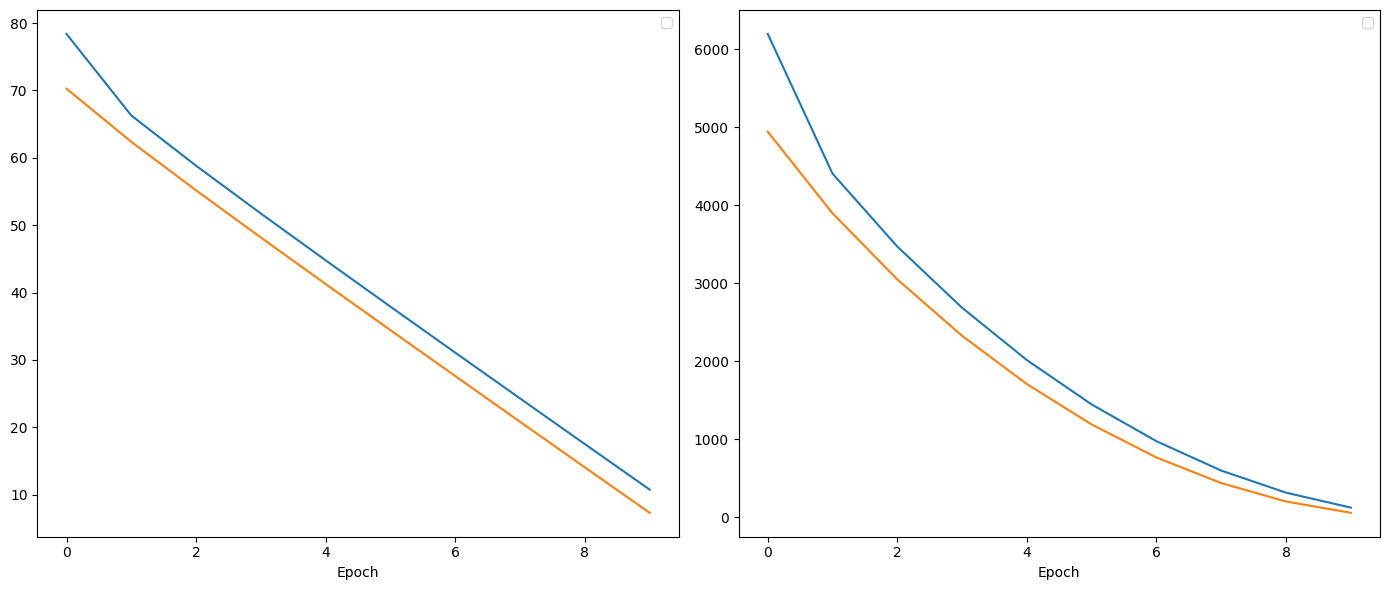

In [33]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ================================================================
# График потерь (Loss)
# ================================================================

axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_xlabel('Epoch')
axes[0].legend()

# ================================================================
# График mse
# ================================================================

axes[1].plot(history.history['mse'])
axes[1].plot(history.history['val_mse'])
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
print('mean_absolute_error:', np.round(mean_absolute_error(y_test, y_pred), 4))
print('mean_absolute_percentage_error:', np.round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('r2_score:', np.round(r2_score(y_test, y_pred), 4))

mean_absolute_error: 7.2391
mean_absolute_percentage_error: 0.0789
r2_score: -11.0614


In [35]:
test['rating_predicted'] = y_pred
test

,rating,text,rating_predicted
0,90.0,Jim Barry Lodge Hill Shiraz 2008. Clare Valley...,83.852638
1,91.0,Argyle Reserve Pinot Noir 2005. Willamette Val...,83.852669
2,87.0,Cambria Katherine's Vineyard Chardonnay 1997. ...,83.852669
3,92.0,Domaine Serene Evenstad Reserve Chardonnay 201...,83.852699
4,90.0,Barnard Griffin Chardonnay 2012. Columbia Vall...,83.852661
...,...,...,...
27416,92.0,Iron Horse Classic Vintage Brut 2005. Sonoma C...,83.852631
27417,92.0,Iron Horse Classic Vintage Brut 2004. Sonoma C...,83.852631
27418,90.0,Iron Horse Classic Vintage Brut 2006. Russian ...,83.852631
27419,93.0,Iron Horse Classic Vintage Brut 2007. Russian ...,83.852142


# Обучение эмбеддинга

In [36]:
# Простейшая модель: вход -> эмбеддинг -> выход (усреднение)
input_ids = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32)
embedding = tf.keras.layers.Embedding(tokenizer.vocab_size, 128, name='embedding')(input_ids)
pooled = tf.keras.layers.GlobalAveragePooling1D()(embedding)
output = tf.keras.layers.Dense(1)(pooled)

model = tf.keras.Model(inputs=input_ids, outputs=output)
model.compile(
    optimizer='adam', 
    loss='mae'
)

# Обучаем
model.fit(train_encodings['input_ids'], y_train, epochs=EPOCHS)

# Забираем обученный эмбеддинг
trained_embeddings = model.get_layer('embedding').get_weights()[0]

Epoch 1/10


I0000 00:00:1779189666.642923  131715 service.cc:153] XLA service 0x7359300b56c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779189666.642942  131715 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779189666.665380  131715 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 14/701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 86.7394

I0000 00:00:1779189667.165304  131715 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.9794 
Epoch 2/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.2240
Epoch 3/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4364
Epoch 4/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9783
Epoch 5/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8785
Epoch 6/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8269
Epoch 7/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.7775
Epoch 8/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.7287
Epoch 9/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6909
Epoch 10/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6610


## Простейшая baseline-модель

### Концепция

Это минимальная архитектура для задачи регрессии текста. Модель не использует рекуррентные или свёрточные слои — только усреднение эмбеддингов. Основная цель — создать быстрый baseline и извлечь обученные векторные представления слов.

### Архитектура

| Слой | Описание |
|------|----------|
| **Input** | Принимает `input_ids` размерности `(batch_size, MAX_LEN)` |
| **Embedding** | Преобразует токены в векторы размерности 128. Веса этого слоя — главный результат обучения |
| **GlobalAveragePooling1D** | Усредняет все векторы токенов по оси времени. Получается один вектор размерности 128 для всего текста |
| **Dense (1 нейрон)** | Линейная проекция на скаляр — предсказание рейтинга |

### Компиляция

- **Оптимизатор:** Adam (стандартный, без настройки параметров)
- **Функция потерь:** MAE (средняя абсолютная ошибка)

### Обучение

Модель обучается на токенизированных текстах (`train_encodings['input_ids']`) с целевыми значениями `y_train` (рейтинги). Количество эпох определяется переменной `EPOCHS`.

### Ключевая цель: извлечение эмбеддингов

После обучения веса embedding-слоя извлекаются с помощью:

```python
trained_embeddings = model.get_layer('embedding').get_weights()[0]

# Тюнинг LSTM

In [37]:
def lstm_model(
    train_encodings,
    y_train,
    val_encodings=None,
    y_val=None,
    lstm_units=64,
    num_lstm_layers=1, 
    learning_rate=3e-4,
    dropout=0,
    loss='mae', 
    embeddings=trained_embeddings, 
    vocab_size=tokenizer.vocab_size,
    max_len=512,
    batch_size=32,
    epochs=20,
    patience=3,
    verbose=1
):
    # --- 1. Архитектура модели ---
    input_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")

    x = tf.keras.layers.Embedding(
        input_dim=vocab_size, 
        output_dim=128, 
        mask_zero=True,
        weights=[trained_embeddings],  # <--- ВСТАВЛЯЕМ ПРЕДОБУЧЕННЫЕ ЭМБЕДДИНГИ
        trainable=False  # False - заморозить эмбеддинги, True - дообучать
    )(input_ids)

    # Добавляем стек LSTM слоев
    for i in range(num_lstm_layers):
        # Если это не последний слой, возвращаем последовательность для следующего
        is_last_lstm = (i == num_lstm_layers - 1)
        
        x = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                units=lstm_units, 
                dropout=dropout,
                return_sequences=not is_last_lstm
            )
        )(x)

    outputs = tf.keras.layers.Dense(1, activation='linear')(x)

    model = tf.keras.Model(inputs=input_ids, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['mse']
    )

    # --- 2. Подготовка данных ---
    x_train_input = train_encodings['input_ids']
    
    validation_data = None
    if val_encodings is not None and y_val is not None:
        validation_data = (val_encodings['input_ids'], y_val)

    # --- 3. Обучение ---
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if validation_data else 'loss', 
            patience=patience, 
            restore_best_weights=True
        )
    ]

    history = model.fit(
        x=x_train_input,
        y=y_train,
        validation_data=validation_data,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    return model, history

## Практика: Конструирование и обучение BiLSTM модели для анализа текстов

В этом разделе мы реализуем гибкую функцию `lstm_model` для создания, компиляции и обучения рекуррентной нейронной сети. Архитектура основана на двунаправленных слоях **LSTM (Bidirectional LSTM)** и использует предобученные эмбеддинги.

---

### 🧱 1. Архитектура и ключевые компоненты модели

Модель принимает на вход токенизированные последовательности фиксированной длины и состоит из следующих этапов обработки:

1. **Входной слой (`Input`)**: Принимает тензоры идентификаторов токенов (`input_ids`) с формой `(max_len,)`.
2. **Слой эмбеддингов (`Embedding`)**: 
   * **Заморозка весов (`trainable=False`)**: Мы используем готовые предобученные векторы (`trained_embeddings`). Веса слоя не обновляются в процессе градиентного спуска, что ускоряет обучение и предотвращает переобучение на небольших датасетах.
   * **Маскирование (`mask_zero=True`)**: Автоматически игнорирует паддинг (нулевые токены) при расчете рекуррентных слоев и функций потерь. Это критически важно для корректной работы LSTM с текстами разной длины.
3. **Рекуррентный блок (`Bidirectional LSTM`)**:
   * Текст обрабатывается в двух направлениях (слева направо и справа налево), что позволяет модели учитывать как прошлый, так и будущий контекст токена.
   * Реализован динамический стек из `num_lstm_layers` слоев. Для всех слоев, кроме последнего, параметр `return_sequences` принудительно устанавливается в `True`, чтобы передать последовательность скрытых состояний на следующий уровень. Последний слой возвращает финальный вектор агрегированного контекста (`return_sequences=False`).
4. **Выходной слой (`Dense`)**: Полносвязный слой с 1 нейроном и линейной активацией (`linear`), оптимизированный под задачу регрессии.

---

### ⚙️ 2. Параметры функции `lstm_model`

| Параметр | Тип / Значение по умолчанию | Описание |
| :--- | :--- | :--- |
| `train_encodings` / `val_encodings` | `dict` | Словари, содержащие `input_ids` для обучающей и валидационной выборок. |
| `y_train` / `y_val` | `array-like` | Целевые переменные (метки/таргеты). |
| `lstm_units` | `int` (64) | Количество скрытых нейронов в одном LSTM-слое. |
| `num_lstm_layers` | `int` (1) | Глубина сети (количество последовательных слоев BiLSTM). |
| `learning_rate` | `float` (3e-4) | Скорость обучения для оптимизатора Adam. |
| `dropout` | `float` (0) | Коэффициент Dropout внутри LSTM слоев для регуляризации. |
| `loss` | `str` ('mae') | Функция потерь. По умолчанию — Mean Absolute Error. |
| `epochs` / `batch_size` | `int` (20 / 32) | Количество эпох обучения и размер мини-батча. |
| `patience` | `int` (3) | Количество эпох ожидания для механизма EarlyStopping. |

---

### 📉 3. Регуляризация и процесс обучения

Для предотвращения переобучения в процесс обучения встроен callback **EarlyStopping**:
* Он отслеживает метрику `val_loss` (при наличии валидационной выборки) или `loss` на трейне.
* Если метрика не улучшается в течение `patience` эпох, обучение прерывается.
* Параметр `restore_best_weights=True` гарантирует, что после остановки модель вернет веса той эпохи, на которой был достигнут наилучший результат, а не последней.

Функция возвращает скомпилированную и обученную `model`, а также объект `history`, содержащий логи метрик по эпохам для последующей визуализации.

In [41]:
def objective(trial):

    lstm_units = trial.suggest_int('lstm_units', 64, 256, step=64)
    num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 3, step=1)
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1)
    loss = trial.suggest_categorical('loss', ['log_cosh', 'mse', 'mae'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True)

    model, history = lstm_model(
        train_encodings=train_encodings,
        y_train=y_train,
        val_encodings=val_encodings,
        y_val=y_val,
        lstm_units=lstm_units,
        num_lstm_layers=num_lstm_layers, 
        learning_rate=learning_rate,
        dropout=dropout,
        loss=loss, 
        embeddings=trained_embeddings, 
        vocab_size=tokenizer.vocab_size,
        max_len=MAX_LEN,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        patience=3,
        verbose=0
    )

    y_pred = model.predict(val_encodings['input_ids'], batch_size=BATCH_SIZE, verbose=0)

    score = mean_absolute_error(y_val, y_pred)

    del model, history, y_pred
    
    gc.collect()
    tf.keras.backend.clear_session()

    return score

## Автоматический подбор гиперпараметров с помощью Optuna

Чтобы не подбирать архитектуру сети вручную, мы используем библиотеку **Optuna**. Процесс оптимизации строится вокруг **целевой функции (Objective Function)**, которую Optuna максимизирует или минимизирует. В нашем случае мы будем *минимизировать* ошибку модели на валидационной выборке.

---

### 🎯 1. Концепция Целевой Функции `objective(trial)`

Функция принимает объект `trial` (испытание), с помощью которого мы задаем пространство поиска (интервалы и типы данных) для каждого гиперпараметра:

*   **`trial.suggest_int`**: Задает поиск целых чисел в указанном диапазоне с определенным шагом.
    *   `lstm_units`: количество нейронов от 64 до 512 (шаг 64).
    *   `num_lstm_layers`: глубина стека BiLSTM от 1 до 4 слоев (шаг 1).
*   **`trial.suggest_float`**: Задает поиск вещественных чисел.
    *   `dropout`: коэффициент зануления связей от 0.0 до 0.5 (шаг 0.1).
    *   `learning_rate`: скорость обучения в диапазоне от $10^{-4}$ до $10^{-3}$. Параметр `log=True` включает логарифмическую шкалу, что позволяет эффективнее сэмплировать малые значения.
*   **`trial.suggest_categorical`**: Выбирает один вариант из текстового списка.
    *   `loss`: выбор функции потерь между `log_cosh`, `mse` и `mae`.

---

### 🚀 2. Алгоритм работы внутри одного испытания

В рамках каждого отдельного `trial` выполняются следующие шаги:
1. **Сэмплирование параметров**: Optuna выбирает комбинацию гиперпараметров на основе истории предыдущих шагов (используя алгоритмы вроде TPE).
2. **Обучение**: Вызывается наша функция `lstm_model` с предложенными параметрами. Флаг `verbose=0` отключает вывод логов обучения, чтобы не засорять консоль.
3. **Валидация**: Построенная модель делает предсказания на валидационной выборке, после чего вычисляется метрика качества — **Mean Absolute Error (MAE)**.
4. **Результат**: Значение MAE возвращается в качестве метрики (`score`), по которой Optuna оценивает успешность данной комбинации параметров.

---

### 🧹 3. Управление памятью и предотвращение утечек (OOM)

При последовательном обучении десятков нейросетей в цикле Optuna оперативная память (RAM/VRAM) может быстро переполниться, что приведет к ошибке *Out of Memory (OOM)*. Для предотвращения этого в конце функции реализована явная очистка:

> *   `del model, history, y_pred` — удаление ссылок на тяжелые объекты модели и прогнозов из локальной области видимости.
> *   `gc.collect()` — принудительный запуск сборщика мусора Python для очистки неочищенной памяти.
> *   `tf.keras.backend.clear_session()` — сброс глобального графа Keras и освобождение памяти видеокарты (VRAM), занятой под веса предыдущей модели.

In [42]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=False
)

study = optuna.create_study(direction='minimize', sampler=sampler)

[I 2026-05-19 16:21:31,854] A new study created in memory with name: no-name-df8b5379-3fbd-46d1-961c-09190a96db3a


In [43]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-19 16:24:35,665] Trial 0 finished with value: 1.5214084509291435 and parameters: {'lstm_units': 192, 'num_lstm_layers': 2, 'dropout': 0.30000000000000004, 'loss': 'mae', 'learning_rate': 0.0001867270003238797}. Best is trial 0 with value: 1.5214084509291435.
[I 2026-05-19 16:25:39,086] Trial 1 finished with value: 1.5715041988030816 and parameters: {'lstm_units': 128, 'num_lstm_layers': 1, 'dropout': 0.5, 'loss': 'log_cosh', 'learning_rate': 0.00016028075037665182}. Best is trial 0 with value: 1.5214084509291435.
[I 2026-05-19 16:27:51,163] Trial 2 finished with value: 1.55700265430129 and parameters: {'lstm_units': 192, 'num_lstm_layers': 2, 'dropout': 0.1, 'loss': 'mae', 'learning_rate': 0.000279711643224792}. Best is trial 0 with value: 1.5214084509291435.
[I 2026-05-19 16:30:49,574] Trial 3 finished with value: 43.42781787269067 and parameters: {'lstm_units': 64, 'num_lstm_layers': 2, 'dropout': 0.1, 'loss': 'mae', 'learning_rate': 0.0001437006202962963}. Best is trial 0

In [44]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=True)
trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_dropout,params_learning_rate,params_loss,params_lstm_units,params_num_lstm_layers,state
41,41,1.494926,2026-05-19 18:06:16.773624,2026-05-19 18:07:58.626254,0 days 00:01:41.852630,0.1,0.000171,log_cosh,192,1,COMPLETE
46,46,1.499409,2026-05-19 18:14:26.603144,2026-05-19 18:16:09.964580,0 days 00:01:43.361436,0.2,0.000175,log_cosh,256,1,COMPLETE
35,35,1.499721,2026-05-19 17:52:32.487381,2026-05-19 17:54:14.065420,0 days 00:01:41.578039,0.1,0.000189,log_cosh,256,1,COMPLETE
21,21,1.500828,2026-05-19 17:11:09.749077,2026-05-19 17:12:49.913941,0 days 00:01:40.164864,0.2,0.000155,log_cosh,192,1,COMPLETE
17,17,1.504167,2026-05-19 17:04:47.779119,2026-05-19 17:06:24.403023,0 days 00:01:36.623904,0.5,0.000306,log_cosh,256,1,COMPLETE
31,31,1.504201,2026-05-19 17:41:35.299503,2026-05-19 17:43:20.818040,0 days 00:01:45.518537,0.2,0.000170,log_cosh,256,1,COMPLETE
40,40,1.504934,2026-05-19 18:04:34.824641,2026-05-19 18:06:15.127156,0 days 00:01:40.302515,0.1,0.000218,log_cosh,192,1,COMPLETE
42,42,1.505076,2026-05-19 18:08:00.257529,2026-05-19 18:09:42.772870,0 days 00:01:42.515341,0.1,0.000168,log_cosh,256,1,COMPLETE
36,36,1.505589,2026-05-19 17:54:15.547612,2026-05-19 17:56:10.088819,0 days 00:01:54.541207,0.1,0.000242,log_cosh,256,1,COMPLETE
18,18,1.506058,2026-05-19 17:06:25.442761,2026-05-19 17:08:10.659197,0 days 00:01:45.216436,0.4,0.000169,log_cosh,256,1,COMPLETE


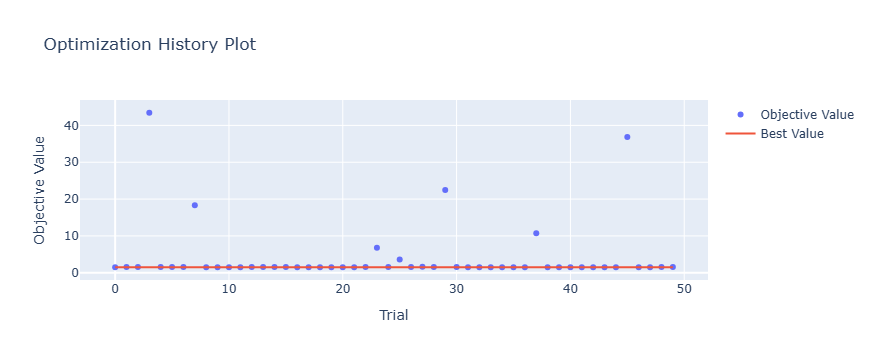

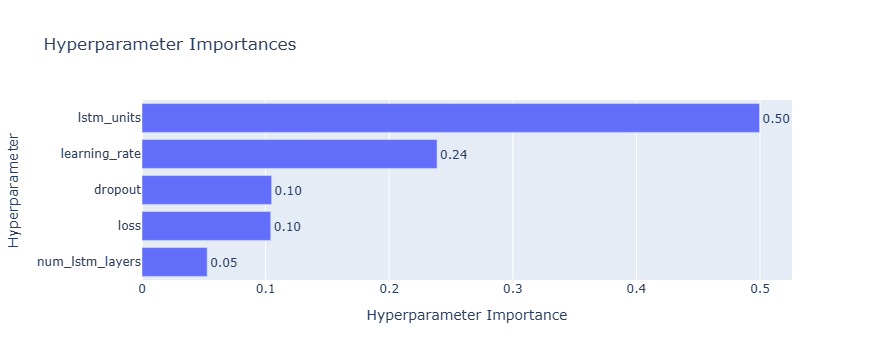

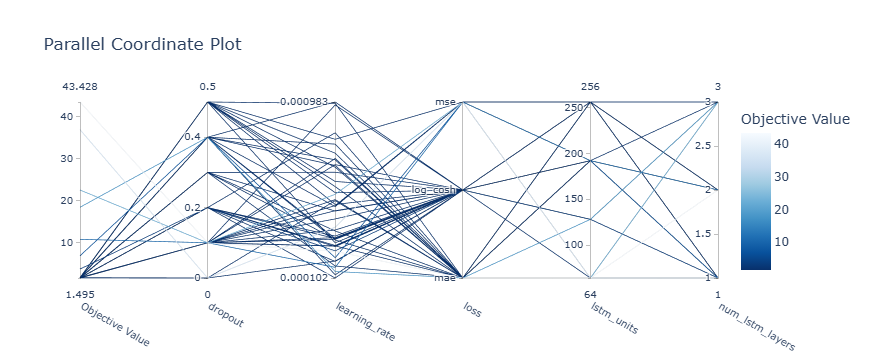

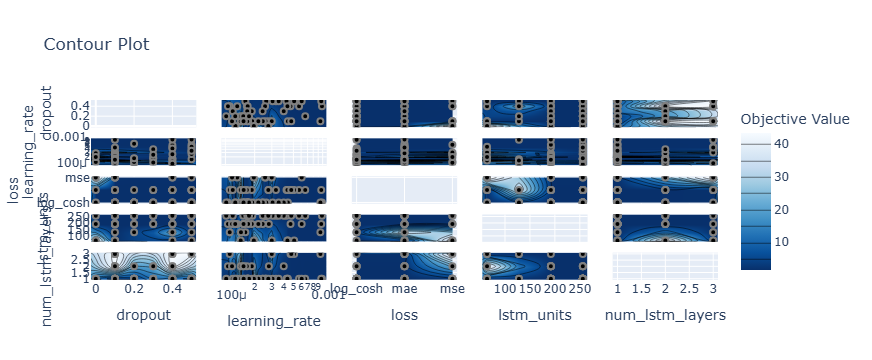

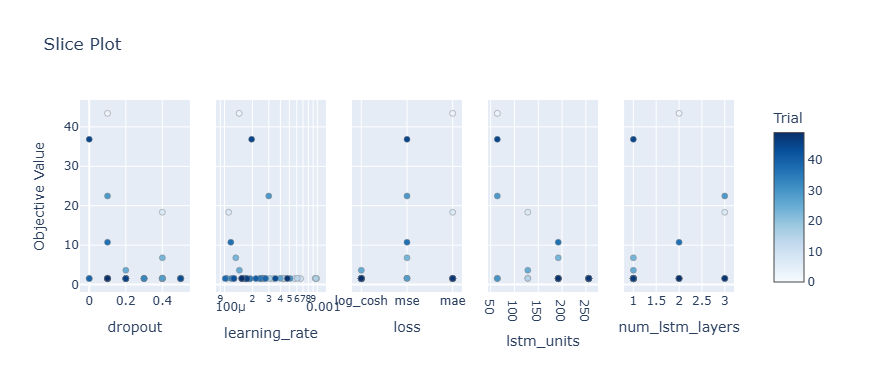

In [45]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()
plot_contour(study).show()
plot_slice(study).show()

In [46]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'lstm_units': 192, 'num_lstm_layers': 1, 'dropout': 0.1, 'loss': 'log_cosh', 'learning_rate': 0.00017134759987372776}
Лучший value: 1.4949262838448043


# Тестовая выборка

In [47]:
LSTM_UNITS = 192
NUM_LSTM_LAYERS = 1
DROPOUT = 0.1
LOSS = 'log_cosh'
LEARNING_RATE = 0.00017134759987372776

In [48]:
model, history = lstm_model(
    train_encodings=train_encodings,
    y_train=y_train,
    val_encodings=val_encodings,
    y_val=y_val,
    lstm_units=LSTM_UNITS,
    num_lstm_layers=NUM_LSTM_LAYERS, 
    learning_rate=LEARNING_RATE,
    dropout=DROPOUT,
    loss=LOSS, 
    embeddings=trained_embeddings, 
    vocab_size=tokenizer.vocab_size,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=3,
    verbose=1
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 65.2157 - mse: 4437.0693 - val_loss: 53.9960 - val_mse: 2995.3267
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - loss: 47.6328 - mse: 2353.5991 - val_loss: 41.2436 - val_mse: 1763.1172
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 35.2635 - mse: 1309.8069 - val_loss: 29.1321 - val_mse: 893.9686
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 23.2730 - mse: 590.9449 - val_loss: 17.2389 - val_mse: 325.9837
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 11.3944 - mse: 162.6388 - val_loss: 5.3767 - val_mse: 41.2092
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - loss: 2.0552 - mse: 11.9767 - val_loss: 1.0567 - val_mse: 4.4918
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 1.1235 - mse: 4.9544 - val_loss: 1.0569 - val_mse: 4.4660
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 1.0916 - mse: 4.7772 - val_loss: 1.0096 - val_mse: 4.2103
Epoch 9/10


In [49]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │  3,906,816 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 512)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 384)       │    493,056 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        385 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,387,141 (20.55 MB)

 Trainable params: 493,441 (1.88 MB)

 Non-trainable params: 3,906,816 (14.90 MB)

 Optimizer params: 986,884 (3.76 MB)

In [50]:
y_pred = model.predict(test_encodings['input_ids'], batch_size=BATCH_SIZE, verbose=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


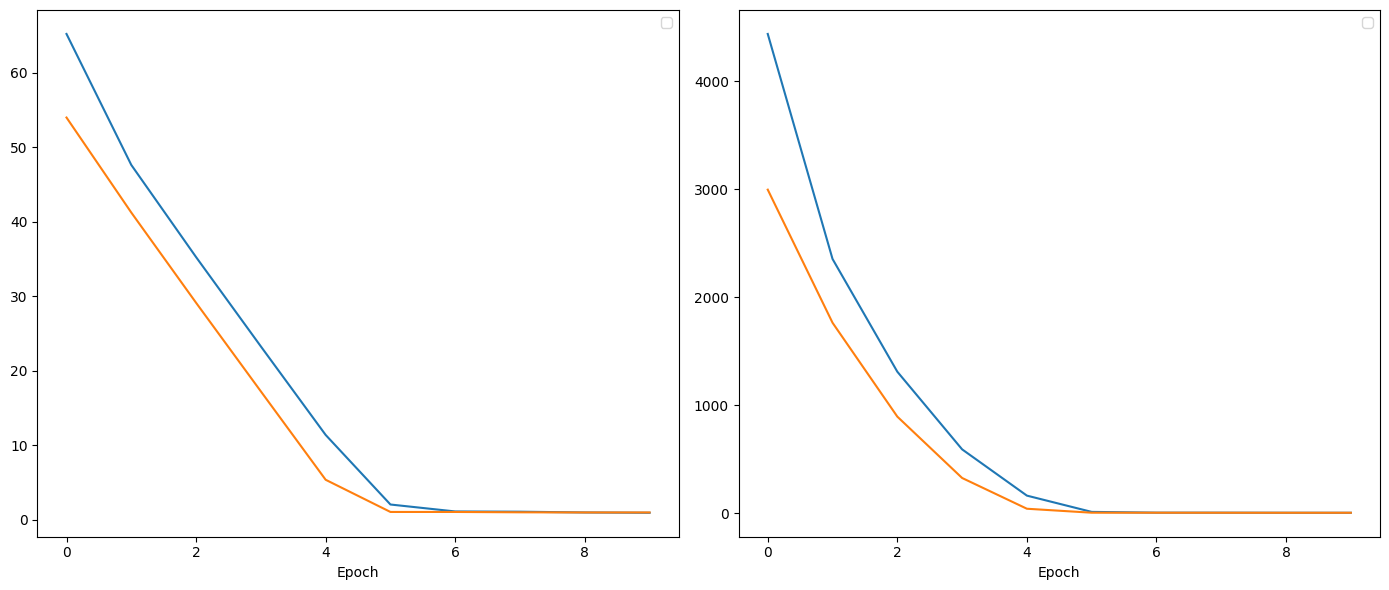

In [51]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ================================================================
# График потерь (Loss)
# ================================================================

axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_xlabel('Epoch')
axes[0].legend()

# ================================================================
# График mse
# ================================================================

axes[1].plot(history.history['mse'])
axes[1].plot(history.history['val_mse'])
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
print('mean_absolute_error:', np.round(mean_absolute_error(y_test, y_pred), 4))
print('mean_absolute_percentage_error:', np.round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('r2_score:', np.round(r2_score(y_test, y_pred), 4))

mean_absolute_error: 1.5628
mean_absolute_percentage_error: 0.0171
r2_score: 0.0756


In [53]:
test['rating_predicted'] = np.round(y_pred, 0)
test

,rating,text,rating_predicted
0,90.0,Jim Barry Lodge Hill Shiraz 2008. Clare Valley...,90.0
1,91.0,Argyle Reserve Pinot Noir 2005. Willamette Val...,91.0
2,87.0,Cambria Katherine's Vineyard Chardonnay 1997. ...,90.0
3,92.0,Domaine Serene Evenstad Reserve Chardonnay 201...,92.0
4,90.0,Barnard Griffin Chardonnay 2012. Columbia Vall...,90.0
...,...,...,...
27416,92.0,Iron Horse Classic Vintage Brut 2005. Sonoma C...,92.0
27417,92.0,Iron Horse Classic Vintage Brut 2004. Sonoma C...,92.0
27418,90.0,Iron Horse Classic Vintage Brut 2006. Russian ...,92.0
27419,93.0,Iron Horse Classic Vintage Brut 2007. Russian ...,92.0


array([[<Axes: title={'center': 'rating_predicted'}>,
        <Axes: title={'center': 'rating'}>]], dtype=object)

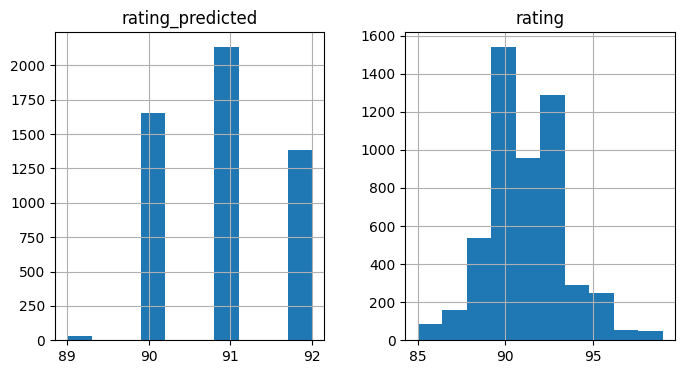

In [54]:
test[['rating_predicted', 'rating']].hist(figsize=[8, 4])